# Quantum models

$\renewcommand{\ket}[1]{\left|#1\right\rangle}\renewcommand{\bra}[1]{\left\langle #1\right|}\renewcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}\renewcommand{\ketbra}[2]{\left|#1\right\rangle\!\left\langle #2\right|}$This notebook details the quantum algorithm used to sample from the stationary distribution and how that is expected to be mapped to the lower level of the software stack. 

## Import


In [2]:
import sys
if ".." not in sys.path:
    sys.path.append("..")  # allows us to import the local package without installing it in editable mode

import numpy as np
import matplotlib.pyplot as plt
from monaqa2.szegedy.quantum_algorithm_spectral_filter2 import plot_spectral_filter_infidelity_vs_degree

## Quantum algorithm for spectral filtering of the Szegedy quantum walk

For a reversible Markov chain, the relevant Hermitian object is the discriminant matrix $X_{yx}=\sqrt{P_{yx}P_{xy}}$, which has the same spectrum as the transition matrix $P$. The Szegedy walk maps an eigenvalue $\lambda$ of $X$ to phases $e^{\pm i\arccos(\lambda)}$. Therefore, an eigenvalue gap $\delta=1-\lambda$ becomes a phase gap $\arccos(1-\delta)\simeq\sqrt{2\delta}$. This gives the quadratic improvement: the filtering cost scales with $1/\sqrt{\delta}$ rather than $1/\delta$.

The filter still needs an initial state with non-negligible overlap with the target stationary state. If this overlap is too small, the projection succeeds with small probability. For this reason, it is necessary to use an annealing-like algorithm where each step is actually a separate spectral filter, reaching stationary distribution of decreasing temperatures: one starts from the uniform distribution and moves through intermediate Gibbs distributions until reaching the target temperature. In the worst case this can require $O(n)$ annealing steps, while for the SK instances considered here the empirical scaling is closer to $O(\sqrt n)$; see `5_runtime.ipynb` and `5.1_heuristic_scheduling.ipynb`. The total cost is dominated by the smallest phase gap along the schedule.

### QSVT-based filtering

The QSVT filter is applied to the Szegedy walk $\widetilde W=V^\dagger S V R_0$, where $R_0=2(I_A\otimes |0\rangle\langle0|_B)-I$. In this frame, the signal projector is simply the computational $B=0$ projector. The circuit uses alternating applications of $\widetilde W$ and $\widetilde W^\dagger$, plus projector phases; no controlled walk operations are required. At the end, projecting onto the block-encoded signal subspace ensures that the non-unitary filter has been applied: an input state $\ket{\psi}$ gives projected component $F\ket{\psi}$, with success probability $p_{\mathrm{succ}}=|F\ket{\psi}|^2$ and conditioned output $F\ket{\psi}/\|F\ket{\psi}\|$.

The filter polynomial is an even Chebyshev filter. In fact, for spectral gap $\delta$, one possible choice is
$$
p_d(x)=\frac{T_{\frac{d}{2}}\left(\frac{2x^2}{(1-\delta)^2}-1\right)}{T_{\frac{d}{2}}\left(\frac{2}{(1-\delta)^2}-1\right)}
$$
for even degree $d$. This preserves $p_d(1)=1$ and suppresses the unwanted region $|x|\le 1-\delta$. 

Let $\Pi_k=\ketbra{\pi_k}{\pi_k}$ be the ideal filter and let $F_k=\Pi_k+R_k$ be the actual filter implemented through the even Chebyshev polynomial. We require the residual leakage to satisfy $\|R_k\|_{\mathrm{op}}\le\varepsilon$. We have
$$
\|R_k\|_{\mathrm{op}}=\max_{\lambda:|\lambda|<1} |p_d(\lambda)|.
$$
Then
$$
\begin{aligned}
\varepsilon&=\max_{\lambda:|\lambda|<1} |p_d(\lambda)| \le \frac{1}{T_{\frac d2}\left(\frac{2}{(1-\delta)^2}-1\right)} \\
&= \operatorname{sech}\!\left(\frac d2\operatorname{arcosh}\!\left(\frac{2}{(1-\delta)^2}-1\right)\right) \\
&\le 2\exp\!\left(-\frac d2\operatorname{arcosh}\!\left(\frac{2}{(1-\delta)^2}-1\right)\right).
\end{aligned}
$$
For small $\delta$, $\operatorname{arcosh}\!\left(\frac{2}{(1-\delta)^2}-1\right)\simeq 2\sqrt{2\delta}$, hence
$$
\varepsilon\lesssim 2e^{-d\sqrt{2\delta}}.
$$
Therefore it is sufficient to choose
$$
d\ge \frac{2\log(2/\varepsilon)}{\operatorname{arcosh}\!\left(\frac{2}{(1-\delta)^2}-1\right)}\approx \frac{\log(2/\varepsilon)}{\sqrt{2\delta}}.
$$

Using an even-degree polynomial is useful because it avoids implementing a parity-indefinite polynomial, which would require an LCU construction and therefore controlled applications of $W$, making the circuit more expensive.

The function `plot_spectral_filter_infidelity_vs_degree` checks this behavior. Use `include_qsvt=False` to plot only the expected Chebyshev-filter curve at high degree, avoiding PennyLane angle-synthesis issues. Use `include_qsvt=True` to compare the polynomial prediction with the PennyLane QSVT statevector simulation. For large degrees, the current `poly_to_angles` path can become numerically unstable because it uses monomial coefficients; robust high-degree synthesis would require a more stable angle-finding routine.


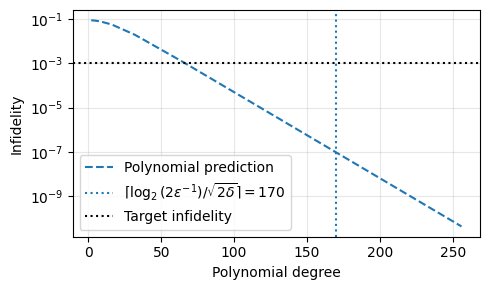

In [4]:
pi = np.array([0.50, 0.25, 0.15, 0.10])
spectral_gap = 0.001
P = (1.0 - spectral_gap) * np.eye(len(pi)) + spectral_gap * pi[:, None]

phase_gap = np.sqrt(2.0 * spectral_gap)
target_suppression = 1e-3
baseline_degree = int(np.ceil(np.log(2.0 / target_suppression) / phase_gap))
degrees = sorted(set([2, 4, 8, 16, 32, 64, 128, 256, baseline_degree]))

fig, ax, data = plot_spectral_filter_infidelity_vs_degree(P, degrees=degrees, include_qsvt=False)
ax.axvline(baseline_degree, linestyle=":", label=rf"$\lceil \log_2(2\varepsilon^{{-1}})/\sqrt{{2\delta}} \rceil = {baseline_degree}$")
ax.axhline(target_suppression, linestyle=":", color="black", label="Target infidelity")
ax.legend()
plt.show()

### Quantum phase estimation based filtering

An alternative would be to use quantum phase estimation on the Szegedy walk. Since eigenvalues $\lambda$ of the discriminant matrix are mapped to phases $\pm\arccos(\lambda)$, QPE can resolve the stationary eigenspace by estimating the walk phase and postselecting, or coherently marking, phases close to zero.

However, this approach requires controlled applications of powers of the walk, such as controlled-$\widetilde W^{2^j}$. This would require redoing the resource analysis for controlled versions of the full walk. In particular, gates that are Clifford in the uncontrolled walk may stop being Clifford once controlled.

The main advantage of QPE is that it writes an estimate of the eigenphase into an explicit register. This is useful if the algorithm needs to use the eigenvalue information later. In our case, however, the eigenvalue is not used as data: we only need to suppress the non-stationary eigenspaces and keep the stationary one. 

### Zeno-rewind approach avoiding exponentially low success probability

Let $\beta_0 = 0 < \ldots < \beta_m$ the inverse temperatures for one annealing schedule that guarantees, for $\ket{\pi_k} = \sum_x \sqrt{\pi_x} \ket{x}$ coherent encoding of the $k$-th Gibbs distribution, that $|\braket{\pi_k}{\pi_{k+1}}|^2 \ge 1/e$. 

If we were to implement the ideal filter $\Pi_k = \ketbra{\pi_k}{\pi_k}$, which can be equivalently implemented via QSVT or QPE-based approaches, we would be in the situation that the consequentive application of the filters has a probability of success of 
$$p_\text{succ} = \prod_{k=0}^{m-1} |\braket{\pi_k}{\pi_k+1}|^2 \ge e^{-m}.$$
The naive repeated postselection is exponentially bad in the number of annealing steps.

A number of solutions are possible here. One could push the success probability to $\approx 1$ using amplitude amplification, at the cost of $O(1)$ applications of the filter (since the success probability of the step is constant). This would give us another layer of complex circuit though. A cheaper approach with the same asymptotic scaling is given by the Zeno-rewind approach. 

Let $p=|\langle \pi_k|\pi_{k+1}\rangle|^2$ and $q=1-p$. By construction of the annealing schedule, $p\ge 1/e$. We can write
$$
\ket{\pi_k}=\sqrt{p}\ket{\pi_{k+1}}+\sqrt{q}\ket{\pi_{k+1}^{\perp}}.
$$
The approach is based on applying an alternating sequence of projectors $\Pi_{k+1},\Pi_k$ until the state $\ket{\pi_{k+1}}$ has been reached. In particular,
$$
\ket{\pi_k} \xrightarrow{\Pi_{k+1}} 
\begin{cases}
    \ket{\pi_{k+1}}, & \text{prob } p, \\
    \ket{\pi_{k+1}^{\perp}}, & \text{prob } q,
\end{cases}
\qquad
\ket{\pi_{k+1}^{\perp}} \xrightarrow{\Pi_k}
\begin{cases}
    \ket{\pi_k}, & \text{prob } q, \\
    \ket{\pi_k^{\perp}}, & \text{prob } p,
\end{cases}
\qquad
\ket{\pi_k^{\perp}} \xrightarrow{\Pi_{k+1}}
\begin{cases}
    \ket{\pi_{k+1}}, & \text{prob } q, \\
    \ket{\pi_{k+1}^{\perp}}, & \text{prob } p.
\end{cases}
$$

Let $C_k$ be the cost of implementing the $k$-th spectral filter. We denote by:
* $T_{k\to k+1}^{(k)}$ the expected cost of reaching $\ket{\pi_{k+1}}$ starting from $\ket{\pi_k}$,
* $T_{k\to k+1}^{(\perp k+1)}$ the same cost starting from $\ket{\pi_{k+1}^{\perp}}$,
* $T_{k\to k+1}^{(\perp k)}$ the same cost starting from $\ket{\pi_k^{\perp}}$.

Then
$$
\begin{aligned}
T_{k\to k+1}^{(k)}
&= C_{k+1}+q T_{k\to k+1}^{(\perp k+1)}, \\
T_{k\to k+1}^{(\perp k+1)}
&= C_k+q T_{k\to k+1}^{(k)}+p T_{k\to k+1}^{(\perp k)}, \\
T_{k\to k+1}^{(\perp k)}
&= C_{k+1}+p T_{k\to k+1}^{(\perp k+1)}.
\end{aligned}
$$

Solving,
$$
T_{k\to k+1}
:=
T_{k\to k+1}^{(k)}
=
\left(1+\frac{1}{2p}\right)C_{k+1}
+
\frac{1}{2p}C_k.
$$
Since $p\ge 1/e$,
$$
T_{k\to k+1}
\le
\left(1+\frac{e}{2}\right)C_{k+1}
+
\frac{e}{2}C_k.
$$
Therefore each annealing transition has only constant expected overhead relative to the cost of the two neighboring filters, rather than an exponentially small success probability from restarting the full annealing path.

## Clifford+$\phi$+CCZ model

The quantum algorithm above is described at the logical-circuit level. However, the raw logical circuit length does not account for the constraints imposed by mapping the computation to an actual fault-tolerant architecture. A reasonable intermediate model is to map the logical circuit to lattice-surgery operations and estimate the execution time on a grid of surface-code patches, without committing to a specific physical qubit platform.

The standard starting point is to express the circuit in the Clifford+$T$ gate set, which is universal. Following the lattice-surgery framework of [A game of surface codes](https://arxiv.org/pdf/1808.02892), the circuit can be rewritten in terms of Pauli Product Rotations (PPRs). Clifford operations are not treated as costly non-Clifford resources; instead, they are propagated through the circuit as updates of a Pauli or Clifford frame, changing the Pauli labels of later PPRs. In the Clifford+$T$ baseline, the remaining non-Clifford operations correspond to $T$-type PPRs.

A PPR can be implemented through a Pauli Product Measurement (PPM) using an ancillary state. Clifford PPRs can use stabilizer ancillas such as $\ket{Y}=(\ket{0}+i\ket{1})/\sqrt{2}$, while $T$-type rotations require non-stabilizer resources such as $\ket{T}=(\ket{0}+e^{i\pi/4}\ket{1})/\sqrt{2}$. The measurement can apply either the desired rotation or its inverse. For $T$-type rotations this is not a serious issue, because the correction is Clifford and can be absorbed into the Pauli or Clifford frame.

The Clifford+$T$ baseline forces every arbitrary rotation $R_z(\theta)$ to be decomposed into a sequence of Clifford+$T$ gates. This introduces a logarithmic overhead in the required synthesis precision. If the circuit contains $N_{\mathrm{rot}}$ arbitrary rotations and the total allowed synthesis error is $\varepsilon_{\mathrm{tot}}$, then one needs $\varepsilon_{\mathrm{rot}}\lesssim \varepsilon_{\mathrm{tot}}/N_{\mathrm{rot}}$, hence $\log(1/\varepsilon_{\mathrm{rot}})=O(\log N_{\mathrm{rot}}+\log(1/\varepsilon_{\mathrm{tot}}))$. In our setting, where the number of walk applications can scale as $N_{\mathrm{rot}}=O(2^{\alpha n})$, this gives an additional $O(\alpha n+\log(1/\varepsilon_{\mathrm{tot}}))$ contribution to the synthesis length of each rotation.

A way to avoid placing these long Clifford+$T$ synthesis sequences directly inside the online circuit is to treat arbitrary rotations as first-class resources. One prepares angle-dependent states such as $\ket{R_z(\theta)}=(\ket{0}+e^{i\theta}\ket{1})/\sqrt{2}$ offline and injects the corresponding rotation during the computation. This is the Clifford+$\phi$ model developed in [A game of surface codes, Sec. 6](https://arxiv.org/pdf/1808.02892). This offline-angle-synthesis viewpoint is also motivated by the Szegedy-walk resource estimates of [Efficient Quantum Walk Circuits for Metropolis-Hastings Algorithm](https://arxiv.org/abs/1910.01659), especially Table 2, where online and offline synthesis of arbitrary single-qubit rotations lead to very different logical-gate-time requirements for achieving a practical speedup.

The important difference from the $T$ case is that an arbitrary $R_z(\theta)$ injection does not have a Clifford correction in general. A failed measurement branch applies the inverse rotation, so the correction requires a rotation by $2\theta$. If that correction also fails, the next correction requires $4\theta$, and so on. Therefore one should prepare not only $\ket{R_z(\theta)}$, but also possible correction states $\ket{R_z(2\theta)},\ket{R_z(4\theta)},\ldots$. With $N$ available correction levels, the probability of having succeeded is $1-2^{-N}$, and the expected number of injected rotations is constant.

We extend this model to Clifford+$\phi$+CCZ. The hybrid phase-arithmetic block contains large Toffoli structure. A Toffoli can be decomposed into Clifford+$T$ gates, but it can also be implemented using a CCZ magic state together with Clifford operations. We therefore track CCZ/Toffoli as a separate non-Clifford resource, rather than forcing every Toffoli through a seven-$T$ decomposition.

This extension is natural because CCZ and arbitrary $R_z(\theta)$ rotations have different correction structures. The $R_z(\theta)$ resource requires an angle-doubling correction cascade, while CCZ lies in the third level of the Clifford hierarchy, so its injection produces Clifford byproduct corrections. These corrections can be tracked in a Clifford frame, or materialized locally when needed. Thus the Clifford+$\phi$+CCZ model has three resource classes: Clifford operations handled by frame tracking and lattice surgery, arbitrary-angle rotations handled by angle-dependent resource states, and Toffoli/CCZ gates handled by dedicated CCZ magic states.





## Error model for the surface code

We use the surface-code error model of [Beverland et al.](https://arxiv.org/abs/2211.07629). Let $V_{\mathrm{st}}$ be the spacetime volume of the logical computation, measured as logical time times logical space. For a physical error rate $p_{\mathrm{phys}}\lesssim10^{-3}$, taken as the representative physical Clifford error rate, the logical error probability per logical round at code distance $d$ is modeled as
$$
p_L(d)=A \, d\, \left(\frac{p_{\mathrm{phys}}}{p_*}\right)^{\frac{d+1}{2}}.
$$
Here, $A = 0.1$ is an empirical prefactor in the surface-code fit, while $p_*=10^{-2}$ corresponds to the approximate threshold value. The factor $d$ accounts for the leading distance-dependent number of logical failure locations.

The total surface-code failure probability is bounded by the spacetime volume $V_{\mathrm{st}}$, i.e. the number of logical qubit-time steps, multiplied by the logical error probability at distance $d$:
$$
p_{\mathrm{SC}}\le V_{\mathrm{st}}p_L(d).
$$
Given a surface-code error budget $\varepsilon_{\mathrm{SC}}$, we choose the smallest odd distance $d\ge 3$ such that
$$
V_{\mathrm{st}}\,0.1d(100p_{\mathrm{phys}})^{(d+1)/2}\le \varepsilon_{\mathrm{SC}}.
$$
In the numerical estimates, $d$ is treated as a continuous effective code distance; an implementable distance can be obtained by rounding up to the next odd integer.

The runtime is obtained from the logical cycle time
$$
\tau_L(d)=d(4\tau_{\mathrm{op}}+\tau_m),
$$
where $\tau_{\mathrm{op}}$ is the physical operation time and $\tau_m$ is the physical measurement time. Therefore, for logical time $D_L$ and logical space $S_L$, with $V_{\mathrm{st}}=D_LS_L$, the surface-code runtime is
$$
T_{\mathrm{SC}}=D_L,d(4\tau_{\mathrm{op}}+\tau_m).
$$

## Comprehensive error budget for the Szegedy quantum walk application

Let $\varepsilon_{\mathrm{TV}}$ be the desired total variation distance error, typically in the range $10^{-2}$ to $10^{-3}$. We split this into independent contributions using a union-bound estimate.

* $\varepsilon_{\mathrm{SC}}=\varepsilon_{\mathrm{TV}}/4$ is the error budget assigned to surface-code logical failures.
* $\varepsilon_{\mathrm{MS}}=\varepsilon_{\mathrm{TV}}/4$ is the error budget assigned to faulty magic-state preparation and injection, including $T$ states, arbitrary-angle $\phi$ states, and CCZ states.
* $\varepsilon_{\mathrm{FLT}}=\varepsilon_{\mathrm{TV}}/4$ is the total error budget assigned to approximating all QSVT spectral filters by finite-degree polynomials.
* $\varepsilon_{\mathrm{W}}$ is the implementation error allowed for a single application of the Szegedy walk $W$ or $W^\dagger$, including the approximation of arbitrary $R_z(\theta)$ rotations appearing inside the walk. If $N_W$ is the total number of walk calls in the full annealing process, then we choose $\varepsilon_{\mathrm{W}}$ such that $N_W\varepsilon_{\mathrm{W}}\le \varepsilon_{\mathrm{TV}}/4$, i.e. $\varepsilon_{\mathrm{W}}=O(\varepsilon_{\mathrm{TV}}/N_W)$. In the worst case, $N_W$ may scale as $N_W=O(2^{\alpha n})$ for some $\alpha>0$, where $n$ is the problem size.

If $m$ denotes the total number of QSVT filter applications budgeted for the full annealing procedure, including the repetitions introduced by the Zeno-rewind step, then the residual leakage of each spectral filter is chosen to be at most $\varepsilon_{\mathrm{FLT}}/m$.